Dataset loaded successfully!
Dataset Shape: (17660, 29)

First 5 rows:
       ID             Name  Age  \
0  209658      L. Goretzka   27   
1  212198  Bruno Fernandes   27   
2  224334         M. Acuña   30   
3  192985     K. De Bruyne   31   
4  224232       N. Barella   25   

                                              Photo Nationality  \
0  https://cdn.sofifa.net/players/209/658/23_60.png     Germany   
1  https://cdn.sofifa.net/players/212/198/23_60.png    Portugal   
2  https://cdn.sofifa.net/players/224/334/23_60.png   Argentina   
3  https://cdn.sofifa.net/players/192/985/23_60.png     Belgium   
4  https://cdn.sofifa.net/players/224/232/23_60.png       Italy   

                                  Flag  Overall  Potential               Club  \
0  https://cdn.sofifa.net/flags/de.png       87         88  FC Bayern München   
1  https://cdn.sofifa.net/flags/pt.png       86         87  Manchester United   
2  https://cdn.sofifa.net/flags/ar.png       85         85         Sevil

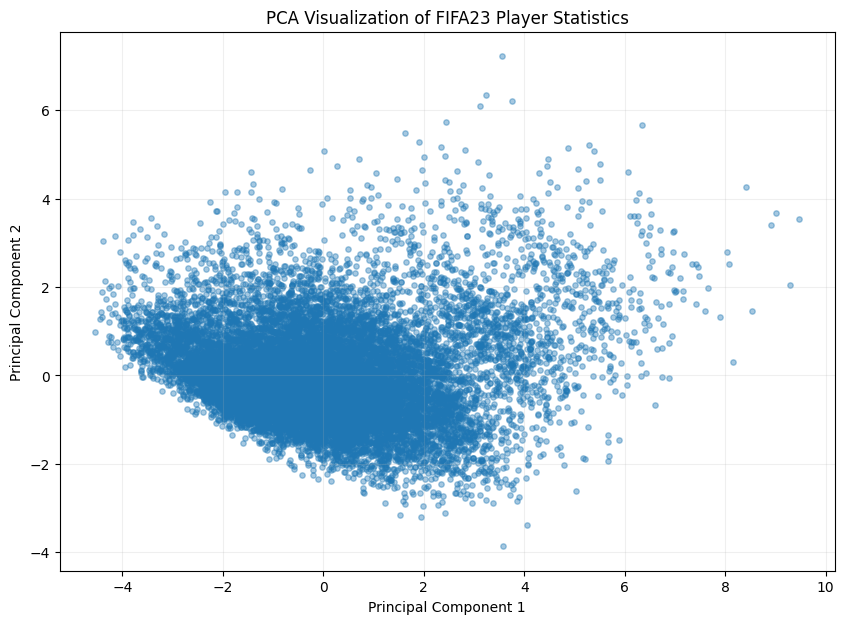

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



UMAP completed.
UMAP Data Shape: (17660, 2)


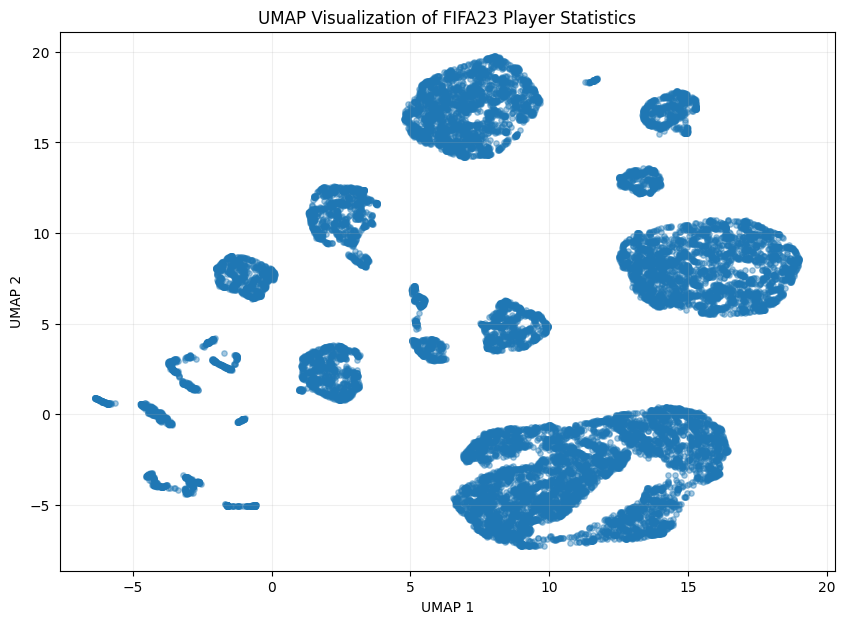


Result Data:
            Player  Age  Overall  Potential     PCA_1     PCA_2    UMAP_1  \
0      L. Goretzka   27       87         88  6.985089  1.942269 -0.606587   
1  Bruno Fernandes   27       86         87  6.185816  0.976431 -3.064759   
2         M. Acuña   30       85         85  4.903523  0.881179 -3.771830   
3     K. De Bruyne   31       91         91  8.535862  1.466011 -0.583287   
4       N. Barella   25       86         89  5.645065  1.079796 -2.962525   
5       J. Kimmich   27       89         90  7.170557  1.913181 -0.605076   
6         D. Alaba   30       86         86  6.948104  2.454897 -0.613481   
7      22 Paulinho   32       83         83  6.438057  1.287959 -4.406605   
8           E. Can   28       82         82  5.552167  1.215238 -3.873120   
9     João Cancelo   28       88         88  6.745713  0.612077 -4.366844   

     UMAP_2  
0 -5.035972  
1 -3.498765  
2 -0.199114  
3 -5.025779  
4 -3.770996  
5 -5.032691  
6 -5.036060  
7 -3.326884  
8 -3.961173 

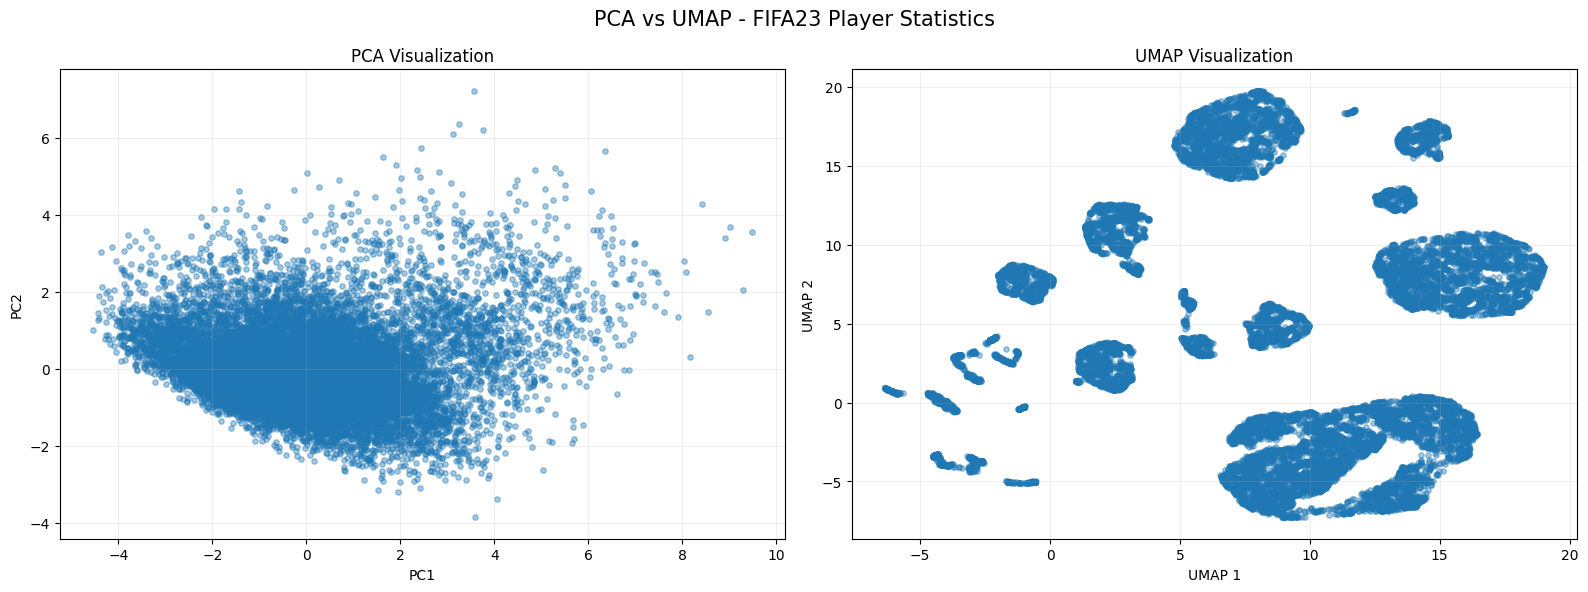


Selected Players:
                Player  Age  Overall  Potential     PCA_1     PCA_2    UMAP_1  \
0          L. Goretzka   27       87         88  6.985089  1.942269 -0.606587   
1      Bruno Fernandes   27       86         87  6.185816  0.976431 -3.064759   
3         K. De Bruyne   31       91         91  8.535862  1.466011 -0.583287   
56            L. Messi   35       91         91  9.009162  3.684896 -0.573756   
100  Cristiano Ronaldo   37       90         90  9.478837  3.542610 -0.543284   
102          Neymar Jr   30       89         89  9.297535  2.049728 -0.568055   

       UMAP_2  
0   -5.035972  
1   -3.498765  
3   -5.025779  
56  -5.020489  
100 -4.987385  
102 -5.012551  


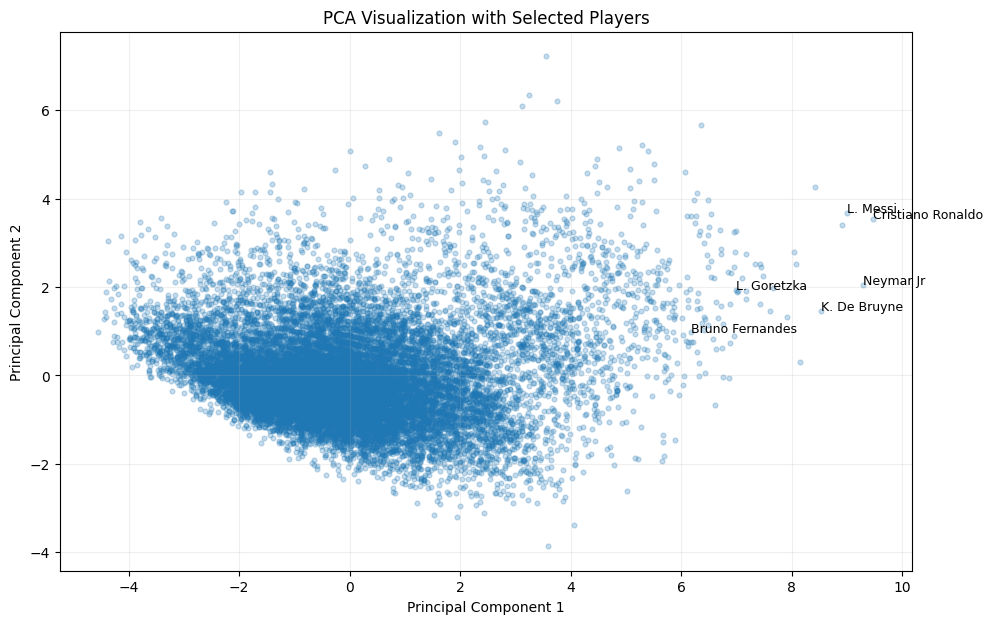

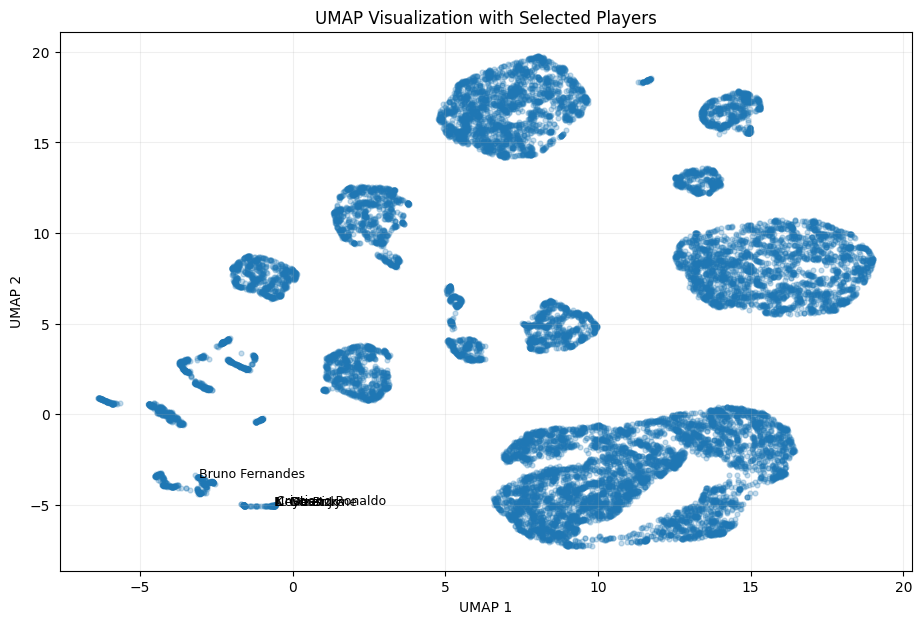


Results saved successfully!
File: FIFA23_PCA_UMAP_Results.csv

          PROJECT SUMMARY
Original Dataset Shape: (17660, 29)
Selected Features: 7
Features Used:
- Age
- Overall
- Potential
- Special
- International Reputation
- Weak Foot
- Skill Moves

PCA Dimensions: 2
UMAP Dimensions: 2

PCA Explained Variance: 64.53 %

PCA and UMAP visualization completed.


In [2]:
# ============================================================
# PLAYER STATISTICS VISUALIZATION USING PCA AND UMAP
# FIFA23 OFFICIAL PLAYER DATASET
# ============================================================


# ============================================================
# 1. INSTALL UMAP
# ============================================================

# Run this only if UMAP is not already installed.
# In Google Colab/Jupyter, uncomment the next line.

# !pip install umap-learn


# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap.umap_ as umap


# ============================================================
# 3. LOAD THE DATASET
# ============================================================

# Change this path if your CSV is stored somewhere else.

file_path = "FIFA23_official_data.csv.zip"

df = pd.read_csv(file_path, compression='zip')

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)


# ============================================================
# 4. BASIC DATASET INFORMATION
# ============================================================

print("\nFirst 5 rows:")
print(df.head())

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())


# ============================================================
# 5. CHECK DATA TYPES
# ============================================================

print("\nData Types:")
print(df.dtypes)


# ============================================================
# 6. CHECK MISSING VALUES
# ============================================================

print("\nMissing Values:")
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])


# ============================================================
# 7. SELECT RELEVANT PLAYER FEATURES
# ============================================================

# These columns are actually available in the FIFA23 dataset.

features = [
    "Age",
    "Overall",
    "Potential",
    "Special",
    "International Reputation",
    "Weak Foot",
    "Skill Moves"
]

X = df[features].copy()

print("\nSelected Features:")
print(features)

print("\nSelected Data:")
print(X.head())


# ============================================================
# 8. HANDLE MISSING VALUES
# ============================================================

print("\nMissing Values in Selected Features:")
print(X.isnull().sum())

# Fill missing numerical values with the median.
X = X.fillna(X.median())

print("\nMissing Values After Cleaning:")
print(X.isnull().sum())


# ============================================================
# 9. CHECK FOR DUPLICATES
# ============================================================

duplicate_count = X.duplicated().sum()

print("\nDuplicate Rows:", duplicate_count)


# ============================================================
# 10. STANDARDIZE THE FEATURES
# ============================================================

# Standardization is important because the selected
# features have different numerical ranges.

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nStandardization completed.")
print("Standardized Data Shape:", X_scaled.shape)


# ============================================================
# 11. APPLY PCA
# ============================================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("\nPCA completed.")
print("PCA Data Shape:", X_pca.shape)


# ============================================================
# 12. PCA EXPLAINED VARIANCE
# ============================================================

explained_variance = pca.explained_variance_ratio_

print("\nPCA Explained Variance:")

print("PC1:",
      round(explained_variance[0] * 100, 2), "%")

print("PC2:",
      round(explained_variance[1] * 100, 2), "%")

print("Total Explained Variance:",
      round(explained_variance.sum() * 100, 2), "%")


# ============================================================
# 13. PCA COMPONENT CONTRIBUTIONS
# ============================================================

pca_components = pd.DataFrame(
    pca.components_,
    columns=features,
    index=["PC1", "PC2"]
)

print("\nPCA Component Contributions:")
print(pca_components)


# ============================================================
# 14. PCA 2D VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.4,
    s=15
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "PCA Visualization of FIFA23 Player Statistics"
)

plt.grid(alpha=0.2)

plt.show()


# ============================================================
# 15. APPLY UMAP
# ============================================================

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = umap_model.fit_transform(X_scaled)

print("\nUMAP completed.")
print("UMAP Data Shape:", X_umap.shape)


# ============================================================
# 16. UMAP 2D VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    alpha=0.4,
    s=15
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.title(
    "UMAP Visualization of FIFA23 Player Statistics"
)

plt.grid(alpha=0.2)

plt.show()


# ============================================================
# 17. CREATE RESULT DATAFRAME
# ============================================================

result = pd.DataFrame({
    "Player": df["Name"],
    "Age": df["Age"],
    "Overall": df["Overall"],
    "Potential": df["Potential"],
    "PCA_1": X_pca[:, 0],
    "PCA_2": X_pca[:, 1],
    "UMAP_1": X_umap[:, 0],
    "UMAP_2": X_umap[:, 1]
})

print("\nResult Data:")
print(result.head(10))


# ============================================================
# 18. PCA AND UMAP COMPARISON
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6)
)

# ---------------- PCA ----------------

axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.4,
    s=15
)

axes[0].set_title("PCA Visualization")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[0].grid(alpha=0.2)


# ---------------- UMAP ----------------

axes[1].scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    alpha=0.4,
    s=15
)

axes[1].set_title("UMAP Visualization")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")

axes[1].grid(alpha=0.2)


plt.suptitle(
    "PCA vs UMAP - FIFA23 Player Statistics",
    fontsize=15
)

plt.tight_layout()

plt.show()


# ============================================================
# 19. SELECT SOME PLAYERS FOR LABELING
# ============================================================

players_to_show = [
    "L. Goretzka",
    "Bruno Fernandes",
    "K. De Bruyne",
    "Neymar Jr",
    "L. Messi",
    "Cristiano Ronaldo"
]

selected_players = result[
    result["Player"].isin(players_to_show)
]

print("\nSelected Players:")
print(selected_players)


# ============================================================
# 20. PCA VISUALIZATION WITH SELECTED PLAYERS
# ============================================================

plt.figure(figsize=(11, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.25,
    s=12
)

for _, row in selected_players.iterrows():

    plt.annotate(
        row["Player"],
        (row["PCA_1"], row["PCA_2"]),
        fontsize=9
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "PCA Visualization with Selected Players"
)

plt.grid(alpha=0.2)

plt.show()


# ============================================================
# 21. UMAP VISUALIZATION WITH SELECTED PLAYERS
# ============================================================

plt.figure(figsize=(11, 7))

plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    alpha=0.25,
    s=12
)

for _, row in selected_players.iterrows():

    plt.annotate(
        row["Player"],
        (row["UMAP_1"], row["UMAP_2"]),
        fontsize=9
    )

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.title(
    "UMAP Visualization with Selected Players"
)

plt.grid(alpha=0.2)

plt.show()


# ============================================================
# 22. SAVE THE RESULTS
# ============================================================

result.to_csv(
    "FIFA23_PCA_UMAP_Results.csv",
    index=False
)

print("\nResults saved successfully!")
print("File: FIFA23_PCA_UMAP_Results.csv")


# ============================================================
# 23. FINAL SUMMARY
# ============================================================

print("\n==========================================")
print("          PROJECT SUMMARY")
print("=========================================")

print("Original Dataset Shape:", df.shape)

print("Selected Features:", len(features))

print("Features Used:")
for feature in features:
    print("-", feature)

print("\nPCA Dimensions:", X_pca.shape[1])
print("UMAP Dimensions:", X_umap.shape[1])

print(
    "\nPCA Explained Variance:",
    round(explained_variance.sum() * 100, 2),
    "%"
)

print("\nPCA and UMAP visualization completed.")

print("=========================================")